In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, BaggingClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import cohen_kappa_score
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

In [2]:
#File Upload
df=pd.read_csv("bank-additional-full.csv", sep=';')

In [3]:
# 3. Drop Leakage Feature
df.drop('duration', axis=1, inplace=True)

In [4]:
# 4. Handle "unknown" Values
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].replace('unknown', df[col].mode()[0])

In [5]:
# 5. Encode Target
df['y'] = df['y'].map({'no': 0, 'yes': 1})
# 6. One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)
X_shuffled = df.drop('y', axis=1)
y_shuffled = df['y']

In [6]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from scipy.stats import uniform

# Split
X_train, X_test, y_train, y_test = train_test_split(X_shuffled, y_shuffled, test_size=0.2, random_state=42)


In [7]:
# Model
model = LogisticRegression(max_iter=1000)

# Search space
param_dist = {
    "C": uniform(0.01, 10),
    "solver": ["lbfgs", "liblinear"],
    "max_iter": [500, 1000, 2000]
}

In [8]:
# RandomizedSearchCV

random_search = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=50,
                                   cv=5, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

Best parameters: {'C': np.float64(6.965160864261275), 'max_iter': 500, 'solver': 'lbfgs'}
Best CV accuracy: 0.9014
Test accuracy: 0.8958


c:\Users\karun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time

# Define your classifier here (Logistic Regression)
from sklearn.linear_model import LogisticRegression

clf_name = "Logistic Regression"
clf = LogisticRegression(random_state=42, max_iter=1000)



# Store results
results = []

# KFold Cross-Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
    y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

    # Train
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predict
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    gm = np.sqrt(rec * specificity)
    auc = roc_auc_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Store fold results
    results.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create DataFrame
results_df = pd.DataFrame(results)

# Print
print(f"Results for {clf_name}:")
print(results_df)

# Save to CSV if needed
results_df.to_csv(f"{clf_name.replace(' ', '_')}_metrics.csv", index=False)

c:\Users\karun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\karun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://s

Results for Logistic Regression:
   Fold           Classifier  Accuracy  Precision    Recall  Specificity  \
0     1  Logistic Regression  0.899005   0.649351  0.216450     0.985234   
1     2  Logistic Regression  0.893178   0.615385  0.186047     0.984915   
2     3  Logistic Regression  0.905317   0.707792  0.240088     0.987722   
3     4  Logistic Regression  0.898276   0.643312  0.217672     0.984679   
4     5  Logistic Regression  0.900704   0.642857  0.236324     0.983616   
5     6  Logistic Regression  0.892692   0.680233  0.232143     0.984786   
6     7  Logistic Regression  0.905802   0.647887  0.213953     0.986446   
7     8  Logistic Regression  0.906773   0.688235  0.261161     0.985563   
8     9  Logistic Regression  0.900923   0.691781  0.217672     0.987685   
9    10  Logistic Regression  0.897523   0.709459  0.216942     0.988167   

         F1        GM       FPR       AUC       MCC     Kappa  \
0  0.324675  0.461794  0.014766  0.600842  0.335485  0.284552   


c:\Users\karun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
# Model
from sklearn.tree import DecisionTreeClassifier
model1 = DecisionTreeClassifier()

# Search space
param_dist1 = {

    "max_depth":[5,10,20,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

In [11]:
# DecisionTreeClassifier

random_search = RandomizedSearchCV(model1, param_distributions=param_dist1, n_iter=50,
                                   cv=10, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

c:\Users\karun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 36 is smaller than n_iter=50. Running 36 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 5}
Best CV accuracy: 0.5640
Test accuracy: 0.8987


In [12]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time

# Define your classifier here (Decision Tree)
from sklearn.tree import DecisionTreeClassifier
clf_name = "Decision Tree"
clf = DecisionTreeClassifier()



# Store results
results1 = []

# KFold Cross-Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
    y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

    # Train
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predict
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    gm = np.sqrt(rec * specificity)
    auc = roc_auc_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Store fold results
    results1.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create DataFrame
results1_df1 = pd.DataFrame(results1)

# Print
print(f"Results for {clf_name}:")
print(results1_df1)

# Save to CSV if needed
results1_df1.to_csv(f"{clf_name.replace(' ', '_')}_metrics.csv", index=False)

Results for Decision Tree:
   Fold     Classifier  Accuracy  Precision    Recall  Specificity        F1  \
0     1  Decision Tree  0.840010   0.310940  0.350649     0.901832  0.329603   
1     2  Decision Tree  0.838796   0.298097  0.298097     0.908941  0.298097   
2     3  Decision Tree  0.851663   0.329718  0.334802     0.915689  0.332240   
3     4  Decision Tree  0.833940   0.286822  0.318966     0.899316  0.302041   
4     5  Decision Tree  0.843166   0.325323  0.385120     0.900328  0.352705   
5     6  Decision Tree  0.848750   0.380762  0.376984     0.914523  0.378863   
6     7  Decision Tree  0.846322   0.290722  0.327907     0.906750  0.308197   
7     8  Decision Tree  0.844865   0.306288  0.337054     0.906837  0.320935   
8     9  Decision Tree  0.835357   0.295019  0.331897     0.899288  0.312373   
9    10  Decision Tree  0.838514   0.325626  0.349174     0.903687  0.336989   

         GM       FPR       AUC       MCC     Kappa  Balanced Accuracy  \
0  0.562341  0.098

In [13]:
# Model
from sklearn.ensemble import RandomForestClassifier
model2 = RandomForestClassifier()

# Search space
param_dist2 = {
         "n_estimators":[100,200,300],
    "max_depth":[10,20,None],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}

In [14]:
# RandomForestClassifier

random_search = RandomizedSearchCV(model2, param_distributions=param_dist2, n_iter=15,
                                   cv=10, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

Best parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}
Best CV accuracy: 0.6713
Test accuracy: 0.8992



  SHAP EXPLANATION 


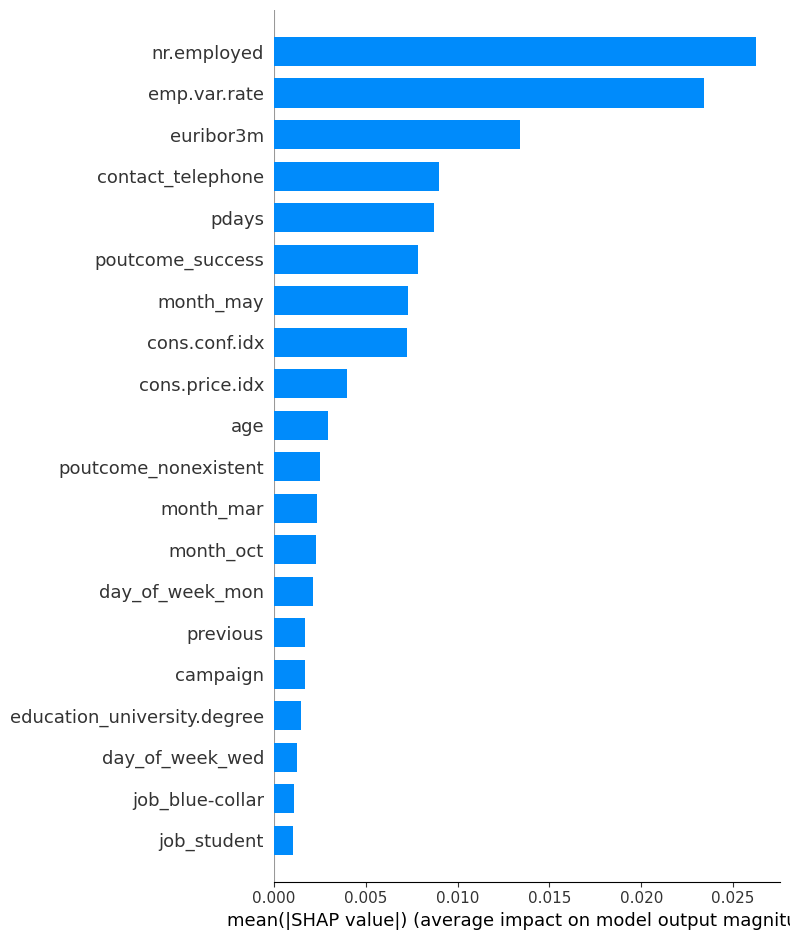

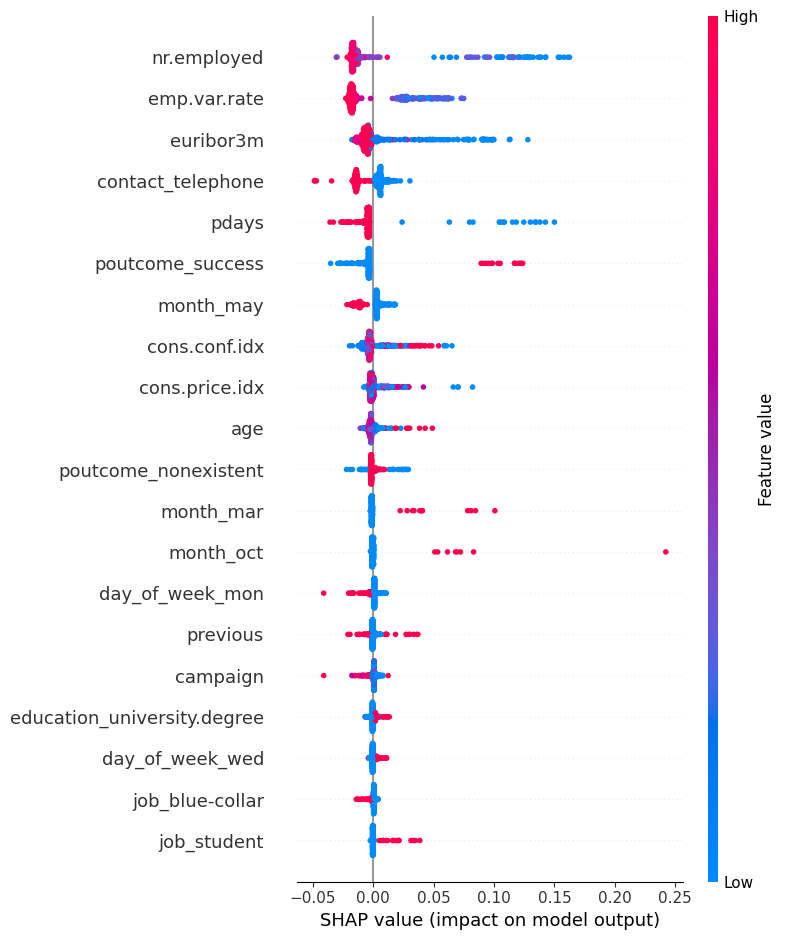

<Figure size 640x480 with 0 Axes>

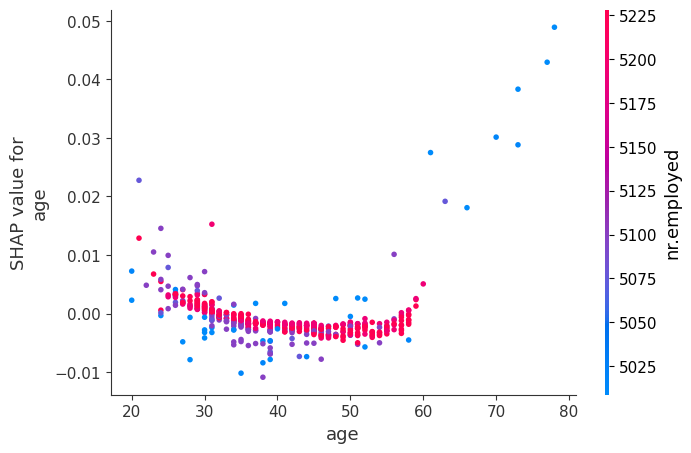

In [19]:
import shap
import matplotlib.pyplot as plt

print("\n  SHAP EXPLANATION ")
shap.initjs()
X_sample = X_train.sample(500,random_state=42)
# Create TreeExplainer
explainer = shap.TreeExplainer(best_model_LR)

# Compute SHAP values
shap_values = explainer.shap_values(X_sample)

# For binary classification → explain class 1
shap_vals = shap_values[:,:,1]

# Global Feature Importance
plt.figure()
shap.summary_plot(shap_vals, X_sample,plot_type="bar")

#  Detailed Summary Plot
plt.figure()
shap.summary_plot(shap_vals, X_sample)

#  Dependence Plot
plt.figure()
shap.dependence_plot(
    X_sample.columns[0],
    shap_vals,
    X_sample
)

#  Force Plot (Single Prediction)


shap.force_plot(
    explainer.expected_value[1],
    shap_vals[0],
    X_sample.iloc[0]
)

In [20]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time

# Define your classifier here (Random Forest)
from sklearn.ensemble import RandomForestClassifier
clf_name = "Random Forest"
clf = RandomForestClassifier()



# Store results
results2 = []

# KFold Cross-Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
    y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

    # Train
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predict
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    gm = np.sqrt(rec * specificity)
    auc = roc_auc_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Store fold results
    results2.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create DataFrame
results2_df2 = pd.DataFrame(results2)

# Print
print(f"Results for {clf_name}:")
print(results2_df2)

# Save to CSV if needed
results2_df2.to_csv(f"{clf_name.replace(' ', '_')}_metrics.csv", index=False)

Results for Random Forest:
   Fold     Classifier  Accuracy  Precision    Recall  Specificity        F1  \
0     1  Random Forest  0.894877   0.554307  0.320346     0.967460  0.406036   
1     2  Random Forest  0.886380   0.510204  0.264271     0.967087  0.348189   
2     3  Random Forest  0.896091   0.555085  0.288546     0.971351  0.379710   
3     4  Random Forest  0.888808   0.511278  0.293103     0.964432  0.372603   
4     5  Random Forest  0.888808   0.498182  0.299781     0.962316  0.374317   
5     6  Random Forest  0.882496   0.537879  0.281746     0.966252  0.369792   
6     7  Random Forest  0.896091   0.504630  0.253488     0.970995  0.337461   
7     8  Random Forest  0.901675   0.588477  0.319196     0.972759  0.413893   
8     9  Random Forest  0.888538   0.510549  0.260776     0.968254  0.345221   
9    10  Random Forest  0.890481   0.556701  0.334711     0.964502  0.418065   

         GM       FPR       AUC       MCC     Kappa  Balanced Accuracy  \
0  0.556707  0.032

In [21]:
# Model
from sklearn.neighbors import KNeighborsClassifier
model3 = KNeighborsClassifier()

# Search space
param_dist3 = {
         "n_neighbors": [3, 5, 7],
            "weights": ["uniform", "distance"]
}

In [22]:
# KNeighbors Classifier

random_search = RandomizedSearchCV(model3, param_distributions=param_dist3, n_iter=25,
                                   cv=15, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

c:\Users\karun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=25. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters: {'weights': 'uniform', 'n_neighbors': 7}
Best CV accuracy: 0.8120
Test accuracy: 0.8919


In [23]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time

# Define your classifier here (KNN)
from sklearn.neighbors import KNeighborsClassifier
clf_name = "KNN"
clf = KNeighborsClassifier()

# Store results
results3 = []




# KFold Cross-Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=15, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
    y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

    # Train
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predict
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    gm = np.sqrt(rec * specificity)
    auc = roc_auc_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Store fold results
    results3.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create DataFrame
results3_df3 = pd.DataFrame(results3)

# Print
print(f"Results for {clf_name}:")
print(results3_df3)

# Save to CSV if needed
results3_df3.to_csv(f"{clf_name.replace(' ', '_')}_metrics.csv", index=False)

Results for KNN:
    Fold Classifier  Accuracy  Precision    Recall  Specificity        F1  \
0      1        KNN  0.891479   0.564706  0.300000     0.969497  0.391837   
1      2        KNN  0.887473   0.508772  0.278846     0.965489  0.360248   
2      3        KNN  0.887473   0.482558  0.273927     0.963569  0.349474   
3      4        KNN  0.900947   0.608187  0.336570     0.972507  0.433333   
4      5        KNN  0.888929   0.506944  0.237785     0.970890  0.323725   
5      6        KNN  0.893299   0.525140  0.311258     0.965221  0.390852   
6      7        KNN  0.887837   0.448864  0.272414     0.960505  0.339056   
7      8        KNN  0.879097   0.510753  0.282738     0.962241  0.363985   
8      9        KNN  0.886744   0.569767  0.292537     0.969307  0.386588   
9     10        KNN  0.887473   0.484848  0.263158     0.965192  0.341151   
10    11        KNN  0.902403   0.543046  0.291815     0.972008  0.379630   
11    12        KNN  0.894028   0.505208  0.331058     0.96

In [24]:
# Model
from sklearn.svm import LinearSVC
model4 = LinearSVC()



from sklearn.svm import LinearSVC

model4 = LinearSVC()

param_dist4 = {
    "C": [0.01, 0.1, 1, 10],
    "loss": ["hinge", "squared_hinge"],
    "max_iter": [1000, 2000]
}

In [25]:
# LinearSVC

random_search = RandomizedSearchCV(model4, param_distributions=param_dist4, n_iter=10,
                                   cv=10, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

Best parameters: {'max_iter': 2000, 'loss': 'hinge', 'C': 0.01}
Best CV accuracy: 0.8645
Test accuracy: 0.8976


c:\Users\karun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



  SHAP EXPLANATION 


100%|██████████| 100/100 [03:33<00:00,  2.14s/it]


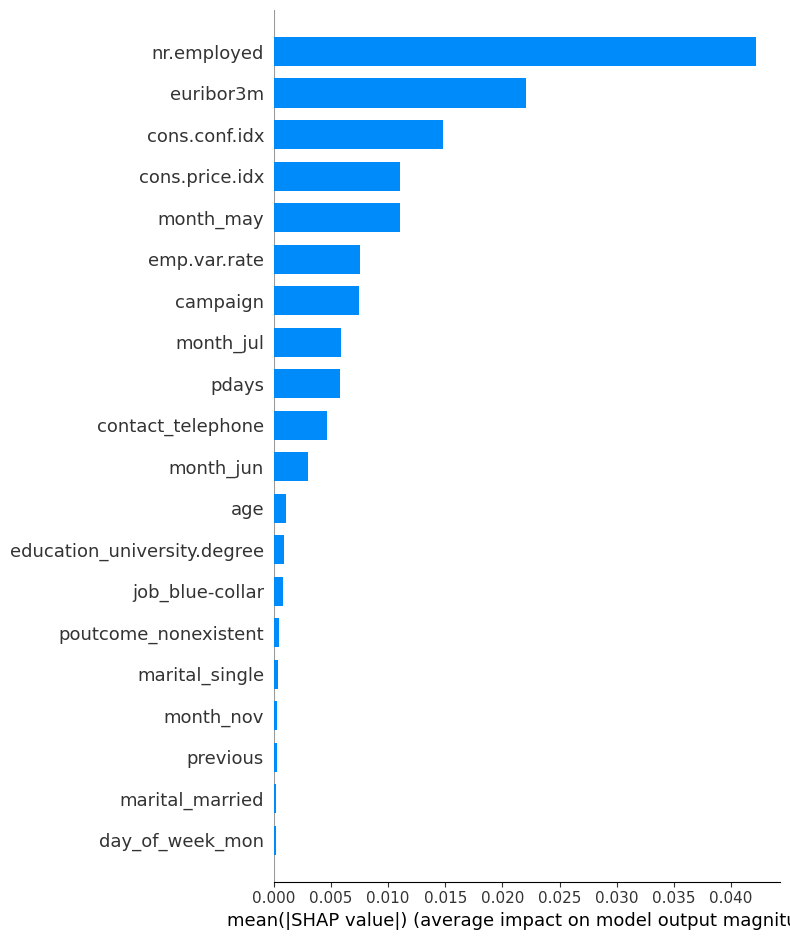

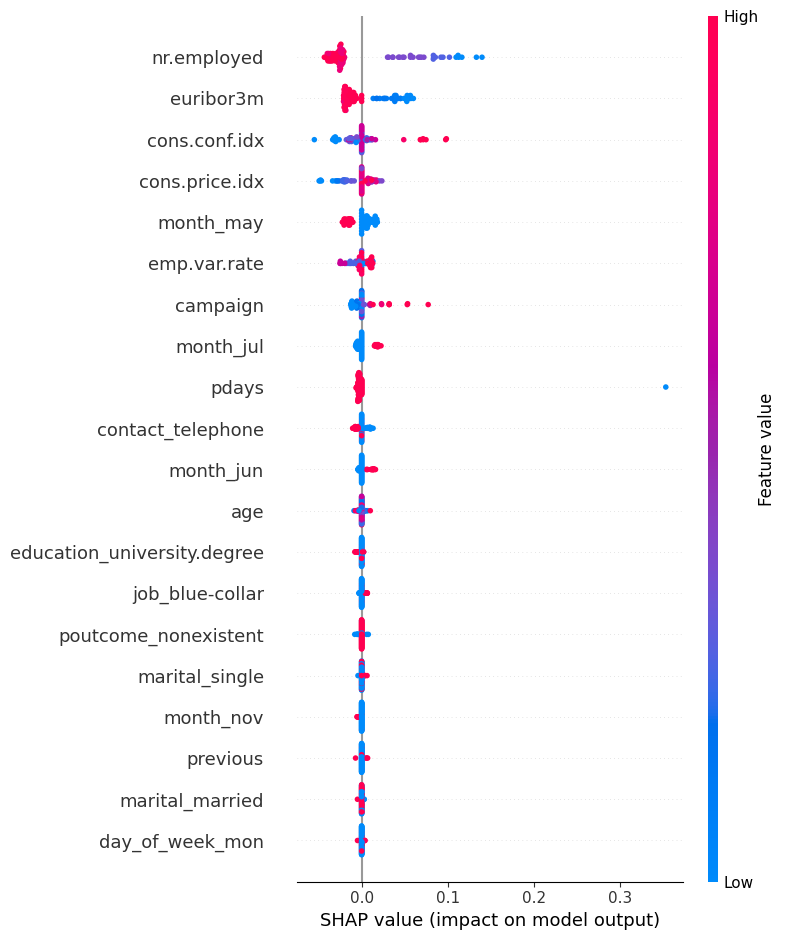

<Figure size 640x480 with 0 Axes>

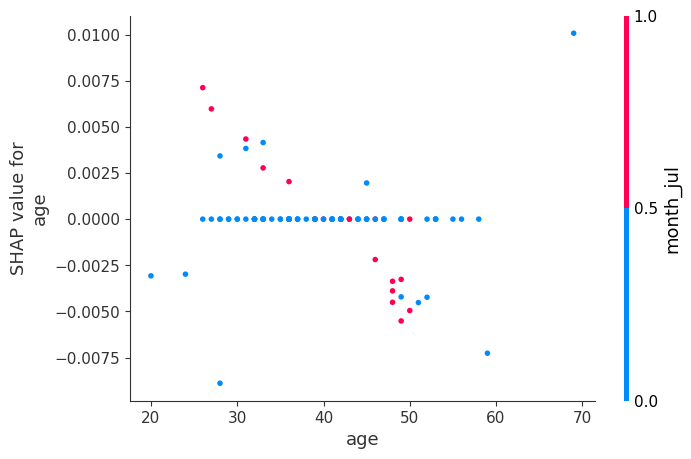

In [28]:
import shap
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV
print("\n  SHAP EXPLANATION ")
svm = CalibratedClassifierCV(best_model_LR)
svm.fit(X_train,y_train)
X_sample = X_train.sample(100,random_state=42)
# Create KernelExplainer
explainer = shap.KernelExplainer(svm.predict_proba,X_sample)

# Compute SHAP values
shap_values = explainer.shap_values(X_sample)

# For binary classification → explain class 1
shap_vals = shap_values[:,:,1]

# Global Feature Importance
plt.figure()
shap.summary_plot(shap_vals, X_sample, plot_type="bar")

#  Detailed Summary Plot
plt.figure()
shap.summary_plot(shap_vals, X_sample)

#  Dependence Plot
plt.figure()
shap.dependence_plot(
    X_sample.columns[0],
    shap_vals,
    X_sample
)

#  Force Plot (Single Prediction)


shap.force_plot(
    explainer.expected_value[1],
    shap_vals[0],
    X_sample.iloc[0]
)

In [29]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time

# Define your classifier here (LinearSVC)
from sklearn.svm import LinearSVC
clf_name = "SVM"
clf = LinearSVC()


# Store results
results4 = []



# KFold Cross-Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=15, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
    y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

    # Train
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predict
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    gm = np.sqrt(rec * specificity)
    auc = roc_auc_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Store fold results
    results4.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create DataFrame
results4_df4 = pd.DataFrame(results4)

# Print
print(f"Results for {clf_name}:")
print(results4_df4)

# Save to CSV if needed
results4_df4.to_csv(f"{clf_name.replace(' ', '_')}_metrics.csv", index=False)

Results for SVM:
    Fold Classifier  Accuracy  Precision    Recall  Specificity        F1  \
0      1        SVM  0.898034   0.712766  0.209375     0.988871  0.323671   
1      2        SVM  0.895849   0.647727  0.182692     0.987264  0.285000   
2      3        SVM  0.897669   0.627907  0.178218     0.986901  0.277635   
3      4        SVM  0.904588   0.747368  0.229773     0.990152  0.351485   
4      5        SVM  0.899490   0.691358  0.182410     0.989750  0.288660   
5      6        SVM  0.900583   0.646465  0.211921     0.985679  0.319202   
6      7        SVM  0.901311   0.602151  0.193103     0.984935  0.292428   
7      8        SVM  0.891843   0.714286  0.193452     0.989212  0.304450   
8      9        SVM  0.894028   0.720000  0.214925     0.988387  0.331034   
9     10        SVM  0.899490   0.652174  0.197368     0.986896  0.303030   
10    11        SVM  0.908230   0.723077  0.167260     0.992698  0.271676   
11    12        SVM  0.907502   0.729412  0.211604     0.99

In [30]:
# Model

from xgboost import XGBClassifier

model5 =  XGBClassifier(use_label_encoder=False, eval_metric='logloss')

param_dist5 = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
            "max_depth": [3, 6]
}

In [31]:
# XGBoost

random_search = RandomizedSearchCV(model5, param_distributions=param_dist5, n_iter=100,
                                   cv=20, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

Best parameters: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01}
Best CV accuracy: 0.8065
Test accuracy: 0.8944



SHAP EXPLANATION 


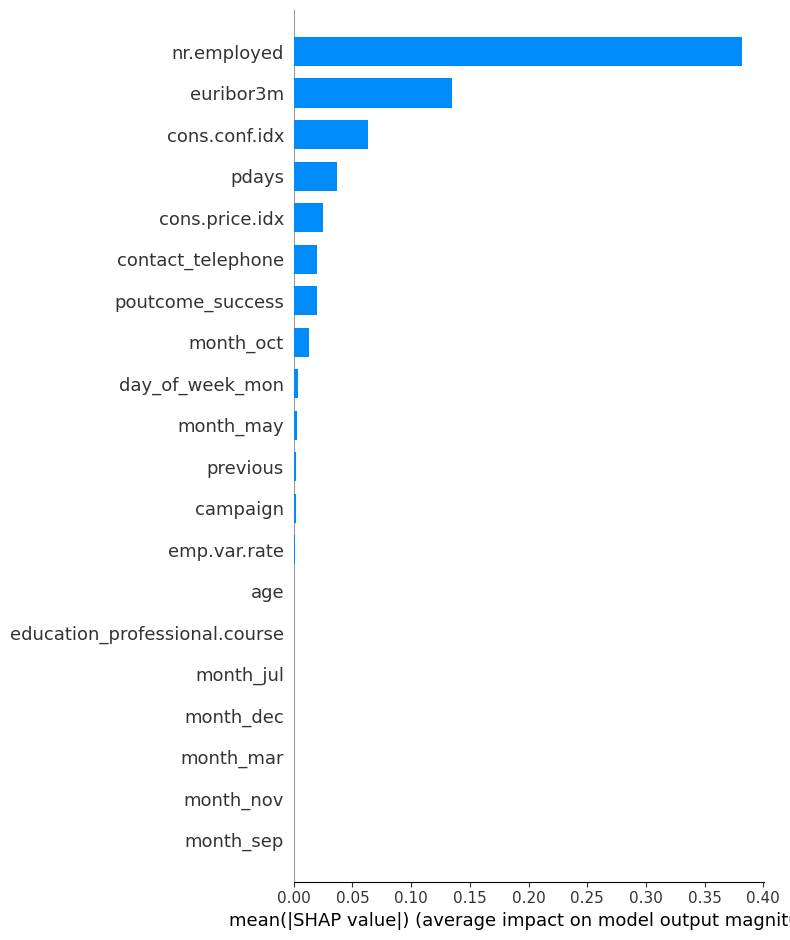

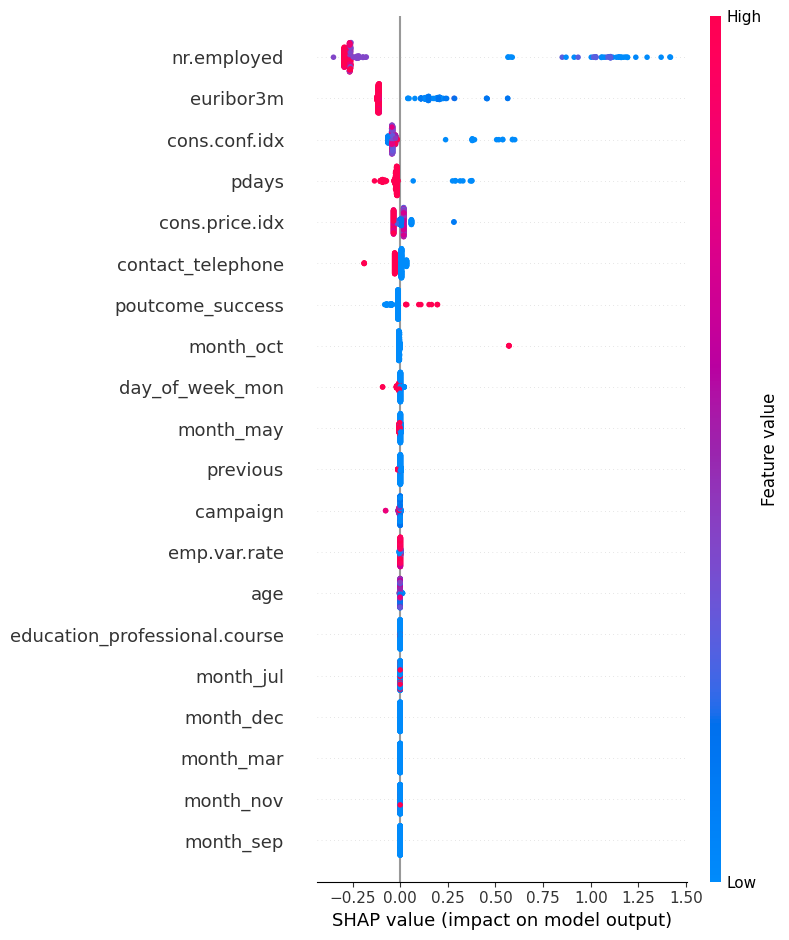

<Figure size 640x480 with 0 Axes>

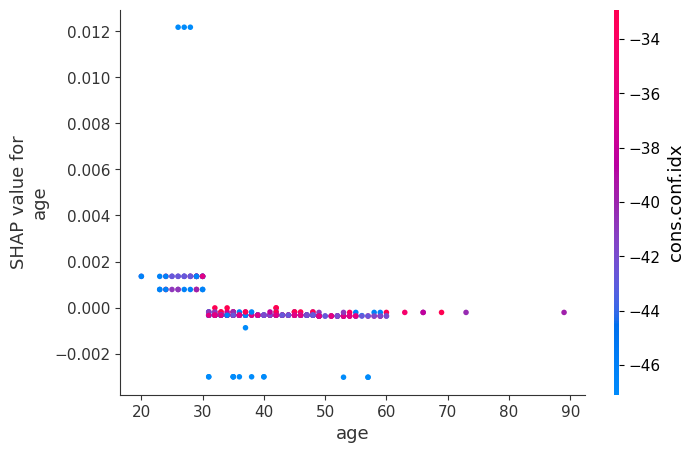

In [51]:
import shap
import numpy as np
import matplotlib.pyplot as plt

print("\nSHAP EXPLANATION ")

#  take small sample (SHAP is slow on full data)
X_sample = X_train.sample(300, random_state=42)

#  create explainer (new universal method)
explainer = shap.Explainer(best_model_LR)

#  generate SHAP values
shap_values = explainer(X_sample)

#  convert to correct matrix (binary classification → class 1)
if len(shap_values.values.shape)==3:
    shap_vals = shap_values.values[:,:, 1]
else:
    shap_vals = shap_values.values
#  Global Feature Importance (Bar)
plt.figure()
shap.summary_plot(shap_vals, X_sample, plot_type="bar")

#  Detailed Beeswarm Summary
plt.figure()
shap.summary_plot(shap_vals, X_sample)

#  Dependence Plot
plt.figure()
shap.dependence_plot(
    X_sample.columns[0],
    shap_vals,
    X_sample
)

#  Force Plot (Single Prediction)
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_vals[0],
    X_sample.iloc[0]
)

In [52]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time

# Define your classifier here (XGBoost)
from xgboost import XGBClassifier
clf_name = "XGBoost"
clf =  XGBClassifier(use_label_encoder=False, eval_metric='logloss')


# Store results
results5 = []



# KFold Cross-Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=15, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
    y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

    # Train
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predict
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    gm = np.sqrt(rec * specificity)
    auc = roc_auc_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Store fold results
    results5.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create DataFrame
results5_df5 = pd.DataFrame(results5)

# Print
print(f"Results for {clf_name}:")
print(results5_df5)

# Save to CSV if needed
results5_df5.to_csv(f"{clf_name.replace(' ', '_')}_metrics.csv", index=False)

Results for XGBoost:
    Fold Classifier  Accuracy  Precision    Recall  Specificity        F1  \
0      1    XGBoost  0.890386   0.559748  0.278125     0.971146  0.371608   
1      2    XGBoost  0.891843   0.551020  0.259615     0.972884  0.352941   
2      3    XGBoost  0.896941   0.571429  0.264026     0.975440  0.361174   
3      4    XGBoost  0.904953   0.671429  0.304207     0.981124  0.418708   
4      5    XGBoost  0.901311   0.625000  0.293160     0.977860  0.399113   
5      6    XGBoost  0.898034   0.568750  0.301325     0.971768  0.393939   
6      7    XGBoost  0.895484   0.509804  0.268966     0.969463  0.352144   
7      8    XGBoost  0.889658   0.610738  0.270833     0.975934  0.375258   
8      9    XGBoost  0.886016   0.572368  0.259701     0.973040  0.357290   
9     10    XGBoost  0.898034   0.593750  0.250000     0.978706  0.351852   
10    11    XGBoost  0.906409   0.592308  0.274021     0.978499  0.374696   
11    12    XGBoost  0.907138   0.631944  0.310580     

In [53]:
# Model LightGBM



model6 =  LGBMClassifier()

param_dist6 = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1]
}

In [54]:
# LightGBM

random_search = RandomizedSearchCV(model6, param_distributions=param_dist6, n_iter=100,
                                   cv=25, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

[LightGBM] [Info] Number of positive: 4327, number of negative: 34116
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002477 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 492
[LightGBM] [Info] Number of data points in the train set: 38443, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112556 -> initscore=-2.064892
[LightGBM] [Info] Start training from score -2.064892
Best parameters: {'n_estimators': 100, 'learning_rate': 0.01}
Best CV accuracy: 0.6616
Test accuracy: 0.8947



SHAP EXPLANATION 


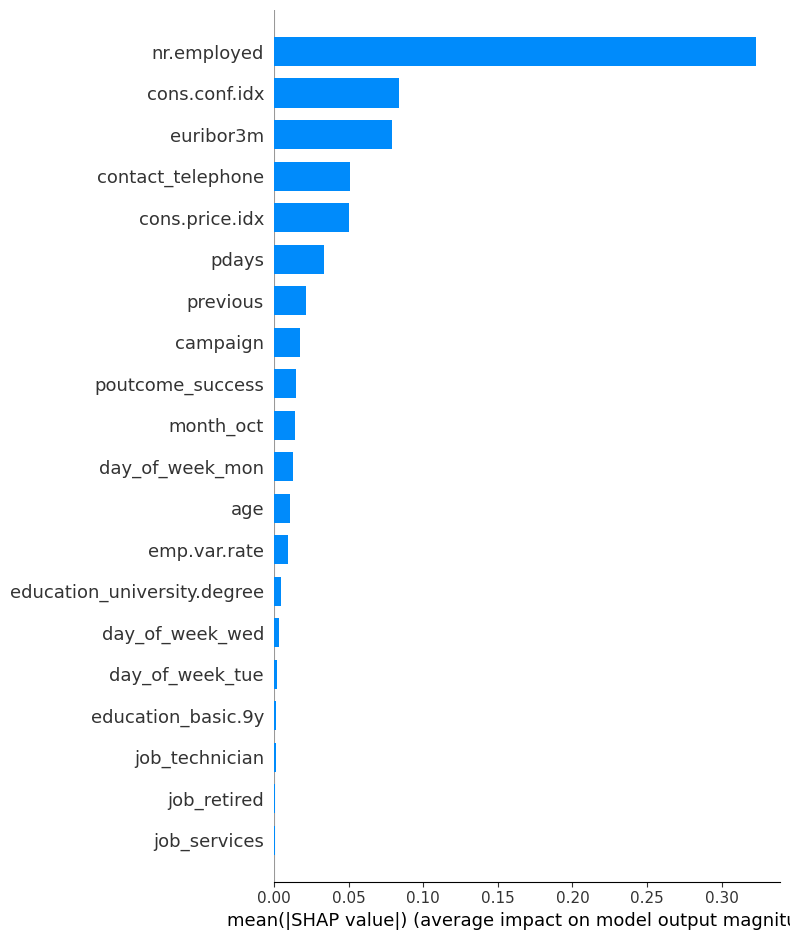

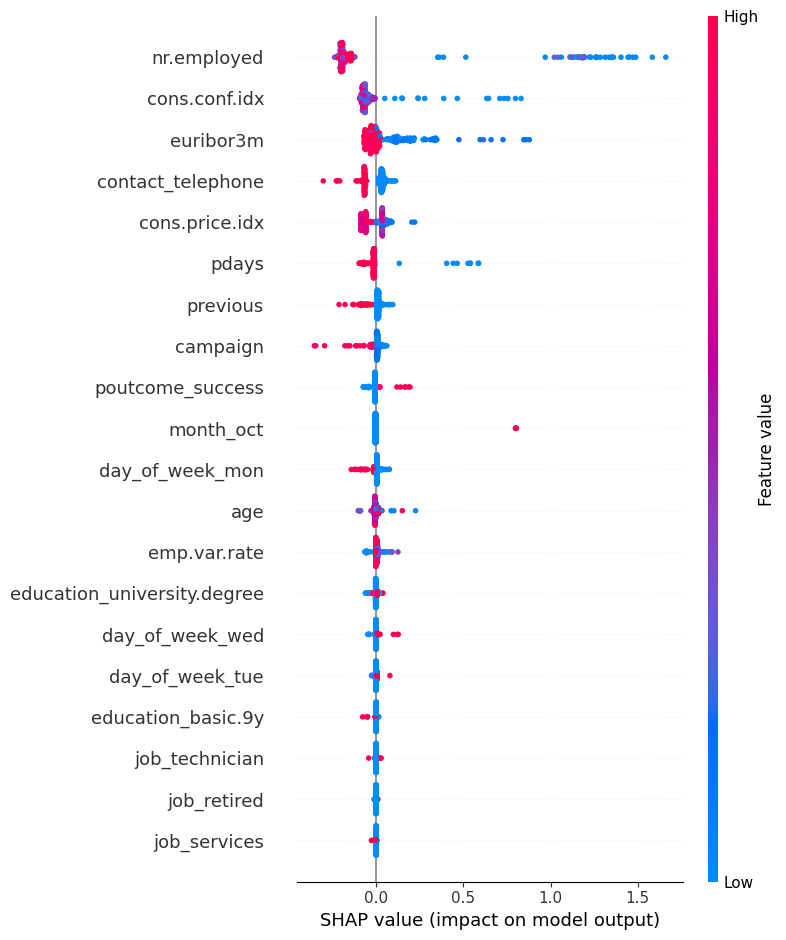

<Figure size 640x480 with 0 Axes>

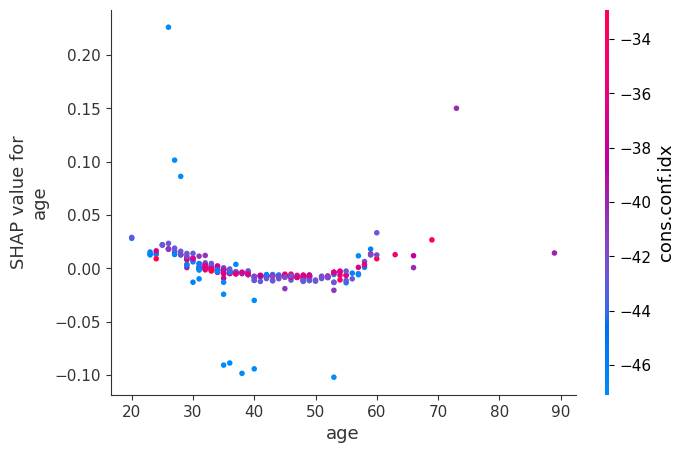

In [56]:
import shap
import numpy as np
import matplotlib.pyplot as plt

print("\nSHAP EXPLANATION ")

#  take small sample (SHAP is slow on full data)
X_sample = X_train.sample(300, random_state=42)

#  create explainer (new universal method)
explainer = shap.Explainer(best_model_LR)

#  generate SHAP values
shap_values = explainer(X_sample)

#  convert to correct matrix (binary classification → class 1)
if len(shap_values.values.shape)==3:
    shap_vals = shap_values.values[:,:, 1]
else:
    shap_vals = shap_values.values
#  Global Feature Importance (Bar)
plt.figure()
shap.summary_plot(shap_vals, X_sample, plot_type="bar")

#  Detailed Beeswarm Summary
plt.figure()
shap.summary_plot(shap_vals, X_sample)

#  Dependence Plot
plt.figure()
shap.dependence_plot(
    X_sample.columns[0],
    shap_vals,
    X_sample
)

#  Force Plot (Single Prediction)
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_vals[0],
    X_sample.iloc[0]
)

In [57]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time

# Define your classifier here (XGBoost)
from lightgbm import LGBMClassifier
clf_name = "LightGBM"
clf =  LGBMClassifier()


# Store results
results6 = []



# KFold Cross-Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=15, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
    y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

    # Train
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predict
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    gm = np.sqrt(rec * specificity)
    auc = roc_auc_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Store fold results
    results6.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create DataFrame
results6_df6 = pd.DataFrame(results6)

# Print
print(f"Results for {clf_name}:")
print(results6_df6)

# Save to CSV if needed
results6_df6.to_csv(f"{clf_name.replace(' ', '_')}_metrics.csv", index=False)

[LightGBM] [Info] Number of positive: 4320, number of negative: 34122
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002496 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 493
[LightGBM] [Info] Number of data points in the train set: 38442, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112377 -> initscore=-2.066687
[LightGBM] [Info] Start training from score -2.066687
[LightGBM] [Info] Number of positive: 4328, number of negative: 34114
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002867 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 493
[LightGBM] [Info] Number of data points in the train set: 38442, number of used features: 44
[LightGBM] [Info] [bin

In [58]:
# Model CatBoost

from catboost import CatBoostClassifier

model7 =   CatBoostClassifier(verbose=0)

param_dist7 = {
     "iterations": [100, 200],
     "depth": [4, 6],
     "learning_rate": [0.01, 0.1]
}

In [59]:
# CatBoost

random_search = RandomizedSearchCV(model7, param_distributions=param_dist7, n_iter=100,
                                   cv=30, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

Best parameters: {'learning_rate': 0.01, 'iterations': 100, 'depth': 4}
Best CV accuracy: 0.8470
Test accuracy: 0.8980


In [60]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time

# Define your classifier here (CatBoost)
from catboost import CatBoostClassifier
clf_name = "CatBoost"
clf =   CatBoostClassifier(iterations=20, verbose=0)


# Store results
results7 = []



# KFold Cross-Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=15, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
    y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

    # Train
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predict
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    gm = np.sqrt(rec * specificity)
    auc = roc_auc_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Store fold results
    results7.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create DataFrame
results7_df7 = pd.DataFrame(results7)

# Print
print(f"Results for {clf_name}:")
print(results7_df7)

# Save to CSV if needed
results7_df7.to_csv(f"{clf_name.replace(' ', '_')}_metrics.csv", index=False)

Results for CatBoost:
    Fold Classifier  Accuracy  Precision    Recall  Specificity        F1  \
0      1   CatBoost  0.896941   0.627586  0.284375     0.977741  0.391398   
1      2   CatBoost  0.895849   0.614035  0.224359     0.981923  0.328638   
2      3   CatBoost  0.899490   0.613445  0.240924     0.981171  0.345972   
3      4   CatBoost  0.907502   0.709924  0.300971     0.984407  0.422727   
4      5   CatBoost  0.900218   0.643478  0.241042     0.983190  0.350711   
5      6   CatBoost  0.899490   0.601562  0.254967     0.979133  0.358140   
6      7   CatBoost  0.898762   0.543478  0.258621     0.974349  0.350467   
7      8   CatBoost  0.896941   0.719008  0.258929     0.985892  0.380744   
8      9   CatBoost  0.891479   0.627586  0.271642     0.977603  0.379167   
9     10   CatBoost  0.902039   0.644628  0.256579     0.982391  0.367059   
10    11   CatBoost  0.908594   0.638889  0.245552     0.984178  0.354756   
11    12   CatBoost  0.907502   0.653543  0.283276    

In [61]:
# Model Gradient Boosting

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier, StackingClassifier

model8 =   GradientBoostingClassifier(n_estimators=25)

param_dist8 = {
      "learning_rate": [0.1, 0.3,0.6],
      "n_estimators": [50, 100],
}

In [62]:
# Gradient Boosting

random_search = RandomizedSearchCV(model8, param_distributions=param_dist8, n_iter=200,
                                   cv=30, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

Best parameters: {'n_estimators': 50, 'learning_rate': 0.1}
Best CV accuracy: 0.7769
Test accuracy: 0.8976


In [63]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time

# Define your classifier here (Gradient Boosting)
from sklearn.ensemble import  GradientBoostingClassifier

clf_name = "Gradient Boosting"
clf =    GradientBoostingClassifier()


# Store results
results8 = []



# KFold Cross-Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=15, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
    y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

    # Train
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predict
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    gm = np.sqrt(rec * specificity)
    auc = roc_auc_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Store fold results
    results8.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create DataFrame
results8_df8= pd.DataFrame(results8)

# Print
print(f"Results for {clf_name}:")
print(results8_df8)

# Save to CSV if needed
results8_df8.to_csv(f"{clf_name.replace(' ', '_')}_metrics.csv", index=False)

Results for Gradient Boosting:
    Fold         Classifier  Accuracy  Precision    Recall  Specificity  \
0      1  Gradient Boosting  0.896941   0.637037  0.268750     0.979802   
1      2  Gradient Boosting  0.894756   0.605505  0.211538     0.982334   
2      3  Gradient Boosting  0.900947   0.632479  0.244224     0.982399   
3      4  Gradient Boosting  0.904953   0.706897  0.265372     0.986048   
4      5  Gradient Boosting  0.904224   0.703704  0.247557     0.986880   
5      6  Gradient Boosting  0.903132   0.642857  0.268212     0.981588   
6      7  Gradient Boosting  0.903860   0.600000  0.268966     0.978827   
7      8  Gradient Boosting  0.894756   0.697479  0.247024     0.985062   
8      9  Gradient Boosting  0.895484   0.676471  0.274627     0.981750   
9     10  Gradient Boosting  0.904588   0.690909  0.250000     0.986077   
10    11  Gradient Boosting  0.908594   0.653061  0.227758     0.986207   
11    12  Gradient Boosting  0.908958   0.677686  0.279863     0.9841

In [64]:
# Model MLP

from sklearn.neural_network import MLPClassifier
model9 =   MLPClassifier(max_iter=300)
param_dist9 = {
      "hidden_layer_sizes": [(64,64), (128,64)]
}

In [65]:
# MLP

random_search = RandomizedSearchCV(model9, param_distributions=param_dist9, n_iter=300,
                                   cv=30, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

Best parameters: {'hidden_layer_sizes': (64, 64)}
Best CV accuracy: 0.8556
Test accuracy: 0.8860


In [66]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time

# Define your classifier here (MLP)
from sklearn.neural_network import MLPClassifier
clf_name = "MLP"
clf =   MLPClassifier(max_iter=500)


# Store results
results9 = []



# KFold Cross-Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=15, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
    y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

    # Train
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predict
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    gm = np.sqrt(rec * specificity)
    auc = roc_auc_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Store fold results
    results9.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create DataFrame
results9_df9= pd.DataFrame(results9)

# Print
print(f"Results for {clf_name}:")
print(results9_df9)

# Save to CSV if needed
results9_df9.to_csv(f"{clf_name.replace(' ', '_')}_metrics.csv", index=False)

Results for MLP:
    Fold Classifier  Accuracy  Precision    Recall  Specificity        F1  \
0      1        MLP  0.875819   0.433121  0.212500     0.963314  0.285115   
1      2        MLP  0.391479   0.148110  0.916667     0.324158  0.255016   
2      3        MLP  0.892935   0.526946  0.290429     0.967663  0.374468   
3      4        MLP  0.903132   0.700935  0.242718     0.986869  0.360577   
4      5        MLP  0.896577   0.618557  0.195440     0.984830  0.297030   
5      6        MLP  0.892207   1.000000  0.019868     1.000000  0.038961   
6      7        MLP  0.880554   0.414414  0.317241     0.947068  0.359375   
7      8        MLP  0.888565   0.641509  0.202381     0.984232  0.307692   
8      9        MLP  0.808449   0.345719  0.638806     0.832020  0.448637   
9     10        MLP  0.896213   0.686275  0.115132     0.993448  0.197183   
10    11        MLP  0.898398   1.000000  0.007117     1.000000  0.014134   
11    12        MLP  0.904588   0.686747  0.194539     0.98

In [67]:
# Model Bagging
from sklearn.ensemble import BaggingClassifier
model10 =   BaggingClassifier(n_estimators=10)
param_dist10 = {
     "n_estimators": [50, 100]
}

In [68]:
# BaggingClassifier

random_search = RandomizedSearchCV(model10, param_distributions=param_dist10, n_iter=500,
                                   cv=30, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

Best parameters: {'n_estimators': 50}
Best CV accuracy: 0.4858
Test accuracy: 0.8871


In [69]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time

# Define your classifier here (BaggingClassifier)
from sklearn.ensemble import BaggingClassifier
clf_name = "BaggingClassifier"
clf =   BaggingClassifier(n_estimators=10)


# Store results
results10 = []



# KFold Cross-Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=25, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
    y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

    # Train
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predict
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    gm = np.sqrt(rec * specificity)
    auc = roc_auc_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Store fold results
    results10.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create DataFrame
results10_df10= pd.DataFrame(results10)

# Print
print(f"Results for {clf_name}:")
print(results10_df10)

# Save to CSV if needed
results10_df10.to_csv(f"{clf_name.replace(' ', '_')}_metrics.csv", index=False)

Results for BaggingClassifier:
    Fold         Classifier  Accuracy  Precision    Recall  Specificity  \
0      1  BaggingClassifier  0.885316   0.504505  0.294737     0.962277   
1      2  BaggingClassifier  0.883495   0.479675  0.315508     0.956194   
2      3  BaggingClassifier  0.893811   0.505376  0.267045     0.968750   
3      4  BaggingClassifier  0.879854   0.479167  0.237113     0.965612   
4      5  BaggingClassifier  0.876214   0.425926  0.244681     0.957534   
5      6  BaggingClassifier  0.886529   0.483333  0.316940     0.957679   
6      7  BaggingClassifier  0.899272   0.567308  0.327778     0.969346   
7      8  BaggingClassifier  0.883495   0.505263  0.248705     0.967698   
8      9  BaggingClassifier  0.887136   0.455357  0.289773     0.958560   
9     10  BaggingClassifier  0.884709   0.482759  0.301075     0.958960   
10    11  BaggingClassifier  0.887136   0.469027  0.296089     0.959156   
11    12  BaggingClassifier  0.888956   0.461538  0.274286     0.9619

In [70]:
# Combine all results into ONE Excel file (multiple sheets)

with pd.ExcelWriter("Final_Results.xlsx") as writer:

    results_df.to_excel(writer, sheet_name="Logistic Regression", index=False)
    results1_df1.to_excel(writer, sheet_name="Decision Tree", index=False)
    results2_df2.to_excel(writer, sheet_name="Random Forest", index=False)
    results3_df3.to_excel(writer, sheet_name="KNN", index=False)
    results4_df4.to_excel(writer, sheet_name="SVM", index=False)
    results5_df5.to_excel(writer, sheet_name="XGBoost", index=False)
    results6_df6.to_excel(writer, sheet_name="LightGBM", index=False)
    results7_df7.to_excel(writer, sheet_name="CatBoost", index=False)
    results8_df8.to_excel(writer, sheet_name="Gradient Boosting", index=False)
    results9_df9.to_excel(writer, sheet_name="MLP", index=False)
    results10_df10.to_excel(writer, sheet_name="Bagging", index=False)

